<a href="https://colab.research.google.com/github/juliaescoriza/Neural-Networks-Deep-Learning/blob/main/Lab03_NN_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning & Generative AI — Lab 3 Fashion-MNIST**

The goal of this session is to build a neural network that classifies **clothing items** into 10 categories (**multi-class classification**). However, note that this notebook **does not work as is**. Your task is to iterate on the code until it meets the requirements.

Fashion-MNIST has exactly the same format as MNIST (28×28 grayscale, 10 classes, 60k training / 10k test samples) but is **considerably more difficult**: T-shirts, sweaters, and coats look very similar at 28×28 pixels. A linear model tops out at ~84%, and a **Dense network hits a ceiling around 90%**.
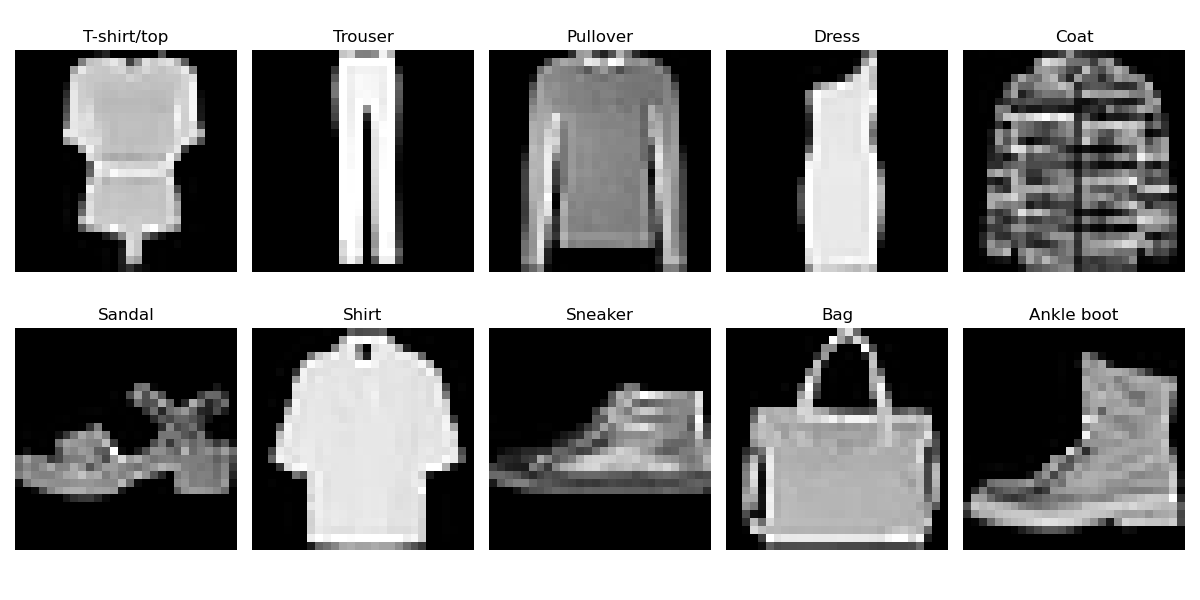

## 0. Import the required Libraries


In [1]:
# Libraries
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Sequential, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import confusion_matrix

# Fashion-MNIST class names
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress',   'Coat',
               'Sandal',      'Shirt',   'Sneaker',  'Bag',     'Ankle boot']

## 1. Load the Dataset

Loading Fashion-MNIST & visualizing some samples

In [2]:
# Load Fashion-MNIST Dataset
(trainX, trainY), (testX, testY) = fashion_mnist.load_data()

# Prepare datapoints to be 4D tensors: (nº samples, Xpixels, Ypixels, channels)
trainX = trainX.reshape(-1, 28, 28, 1)
testX = testX.reshape(-1, 28, 28, 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# TODO 1:
#   a) How many training samples and test samples are there?
#   b) How many samples of each class are there in the training set?
#   c) Is the Dataset balanced?



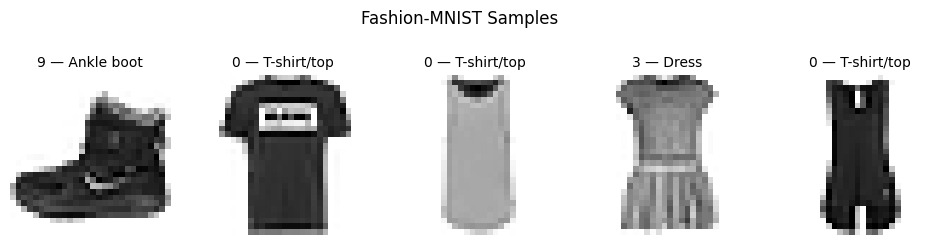

In [3]:
# Plot some samples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('Fashion-MNIST Samples')
for i, ax in enumerate(axes):
    ax.imshow(trainX[i, :, :, 0], cmap='gray_r')
    ax.set_title(f"{trainY[i]} — {CLASS_NAMES[trainY[i]]}", fontsize=10)
    ax.axis('off')

plt.show()

## 2. Data preparation

In [4]:
trainY_encoded = to_categorical(trainY, 10)
testY_encoded  = to_categorical(testY, 10)

## 3. The Deep Learning model

In [27]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

# Use of Adam (Adaptive Moment Estimation) as the parameter optimizer. More info here: https://www.geeksforgeeks.org/deep-learning/adam-optimizer
opt = Adam(learning_rate=1e-04)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Plot information about the model
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(trainX, trainY_encoded, validation_data=(testX, testY_encoded), batch_size=32, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6475 - loss: 3.1527 - val_accuracy: 0.7069 - val_loss: 1.1415
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7493 - loss: 0.9366 - val_accuracy: 0.7652 - val_loss: 0.8486
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7921 - loss: 0.7179 - val_accuracy: 0.7938 - val_loss: 0.7086
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8185 - loss: 0.5894 - val_accuracy: 0.8225 - val_loss: 0.5876
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8385 - loss: 0.5050 - val_accuracy: 0.8276 - val_loss: 0.5459
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8498 - loss: 0.4475 - val_accuracy: 0.8348 - val_loss: 0.5192
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8610 - loss: 0.4088 - val_accuracy: 0.8472 - val_loss: 0.4732
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8687 - loss: 0.3794 - 

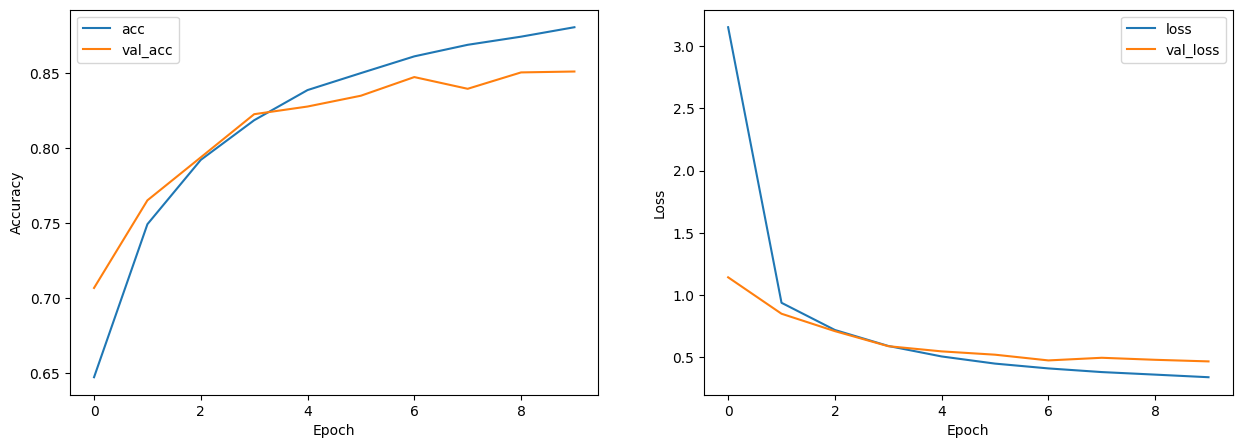

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: accuracy
ax1.plot(history.history['accuracy'], label='acc')
ax1.plot(history.history['val_accuracy'], label='val_acc')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Right: loss
ax2.plot(history.history['loss'], label='loss')
ax2.plot(history.history['val_loss'], label='val_loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

## 5. Testing the network

A number is not an analysis. Let's look at **where** and **why** your model fails.

In [ ]:
predicted = model.predict(testX)
predictedClass = np.argmax(predicted, axis=1)

# Confusion matrix
cm = confusion_matrix(testY, predictedClass)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Efficiency Challenge

In the real world, models run on phones, robots, and embedded devices. Parameters cost memory, latency, and energy.

**The challenge:** reach **≥ 85% validation accuracy** with a model of **≤ 150,000 trainable parameters** (weights + biases)